In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import os

from grid_simulation import get_rgb_map
from cuda_square_simulation import SquareSimulation

In [2]:
def get_results_imgs(simulation, iterations=50,  type1 = 'random', type2 = 'random', type3 = 'random', save_dir=None, title=None):

    pop1_size = []
    pop2_size = []
    pop3_size = []

    for i in range(iterations):
        action_grid = simulation.configurable_actions_grid(type1=type1, type2=type2, type3=type3)
        simulation.step(action_grid)

        pop1_size.append(simulation.grid[:,0].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop2_size.append(simulation.grid[:,1].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop3_size.append(simulation.grid[:,2].sum(dim=(1,2)).mean(dim=0).cpu().numpy())

    # get the final population sizes
    # results = []
    # results.append(pop1_size[-1])
    # results.append(pop2_size[-1])
    # results.append(pop3_size[-1])

    # results.append(pop1_size[-1] / fitness_total * 100)
    # results.append(pop2_size[-1] / fitness_total * 100)
    # results.append(pop3_size[-1] / fitness_total * 100)

    # get the final population sizes
    string_results = '\n'
    string_results+='Final population fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1]}\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1]}\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1]}\n\n'
        
    fitness_total = pop1_size[-1] + pop2_size[-1] + pop3_size[-1]
    string_results+=f'Total fitness: {fitness_total}\n\n'

    string_results+='Final population %\'s fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1] / fitness_total * 100:.2f}%\n'

    print(string_results)


    # Get the final population distribution
    plt.figure()
    
    legend_elements = [
        Patch(facecolor='red', edgecolor='r', label=f'{type1.capitalize()}'),
        Patch(facecolor='blue', edgecolor='b', label=f'{type2.capitalize()}'),
        Patch(facecolor='green', edgecolor='g', label=f'{type3.capitalize()}'),
    ]   
    
    rgb_map = get_rgb_map(simulation, plt)
    plt.imshow(rgb_map)
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1.))  
    plt.axis('off')
    plt.title('Final population distribution')
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_final_distr.pdf'), bbox_inches='tight')

    plt.show()

    # Plot the population size over time
    plt.figure()
    plt.plot(np.arange(iterations), pop1_size, label=f'{type1.capitalize()}', color='red')
    plt.plot(np.arange(iterations), pop2_size, label=f'{type2.capitalize()}', color='blue')
    plt.plot(np.arange(iterations), pop3_size, label=f'{type3.capitalize()}', color='green')
    plt.xlabel('Iterations')
    plt.ylabel('Population Size')
    plt.title('Population Size Over Time')
    plt.legend()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_time_plot.pdf'), bbox_inches='tight')
    plt.show()

    return string_results

Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 26.627552032470703
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 26.627552032470703

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



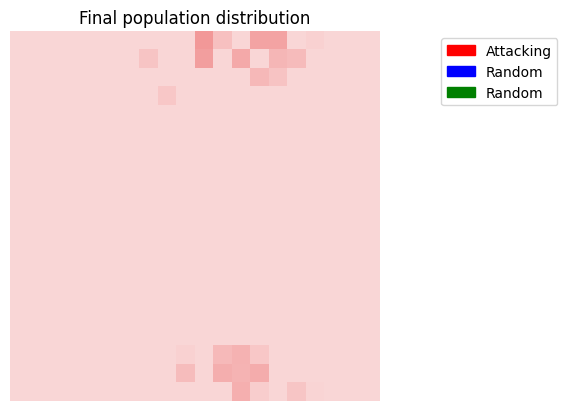

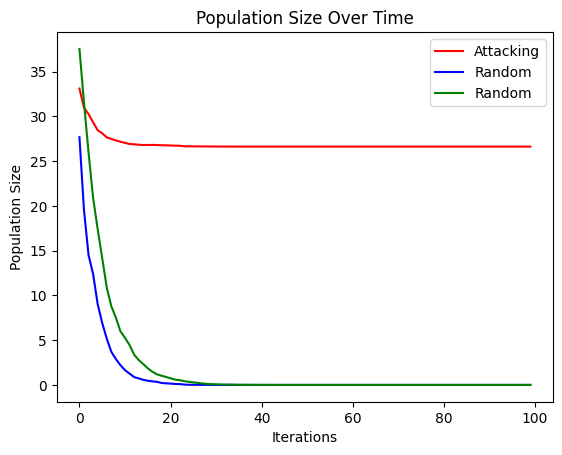

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 3.3170242659252835e-06
Population 2: random - 2.8314600058365613e-05
Population 3: random - 3.4255472201039083e-06

Total fitness: 3.505717177176848e-05

Final population %'s fitness:
Population 1: giving - 9.46%
Population 2: random - 80.77%
Population 3: random - 9.77%



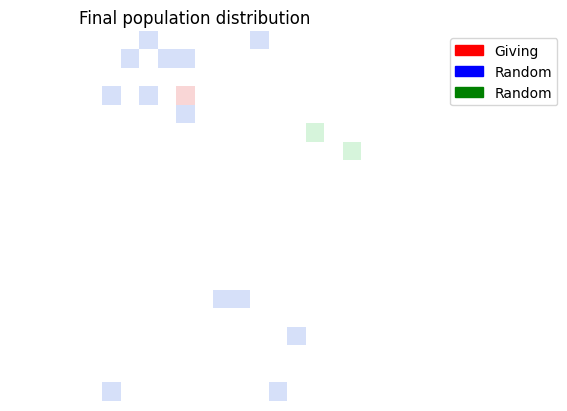

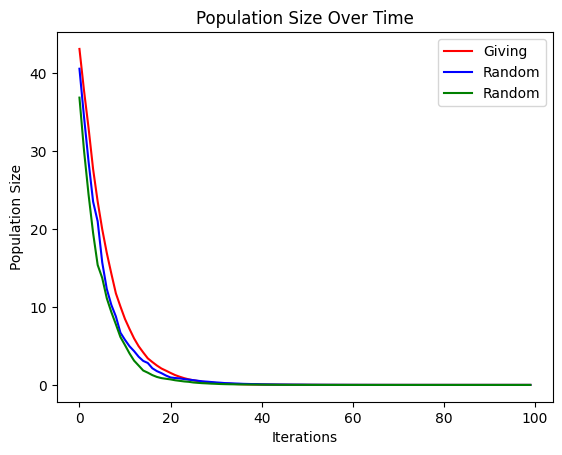

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 0.0
Population 2: random - 0.0
Population 3: random - 3.242001639591763e-06

Total fitness: 3.242001639591763e-06

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: random - 0.00%
Population 3: random - 100.00%



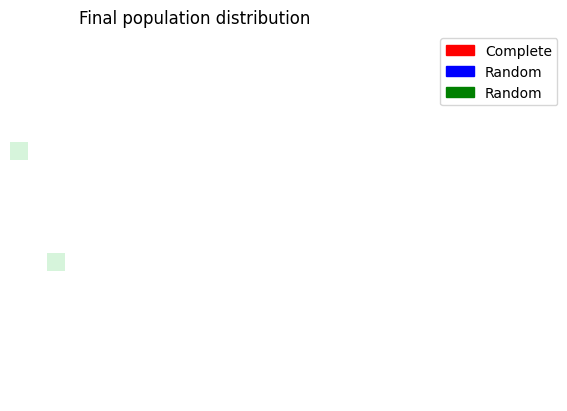

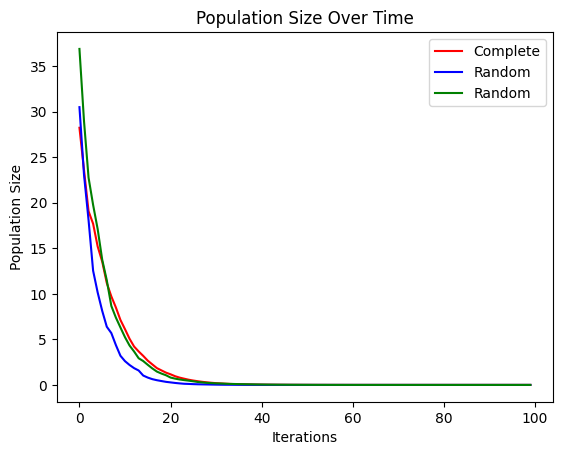

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 32.13134002685547

Total fitness: 32.13134002685547

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



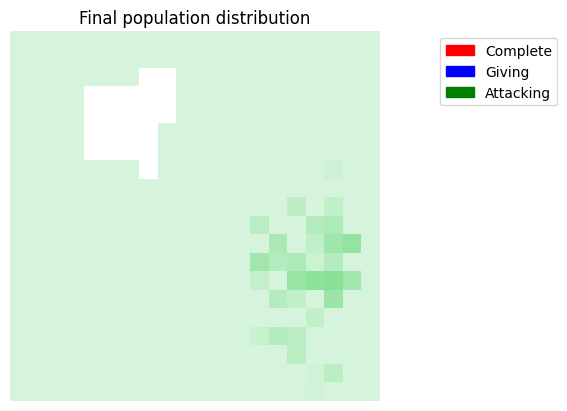

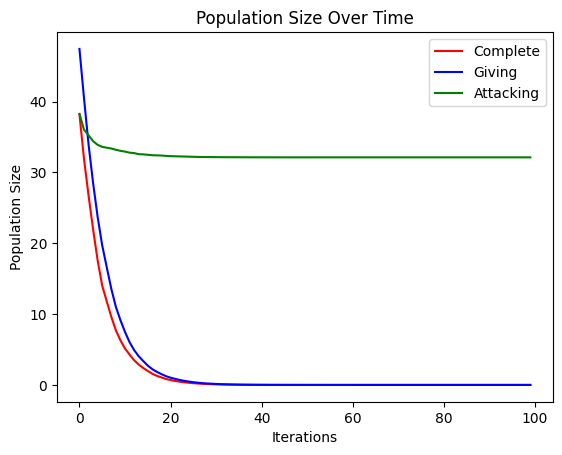

Creating simulation with parameters: bonus_0_1 - fitness_donation: 0.0 - fitness_growth: 0.1
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 3625.677734375
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 3625.677734375

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



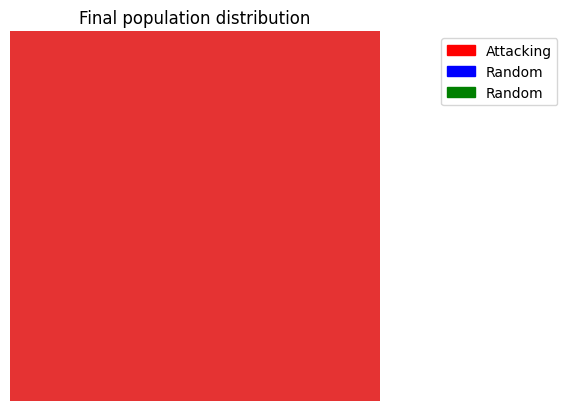

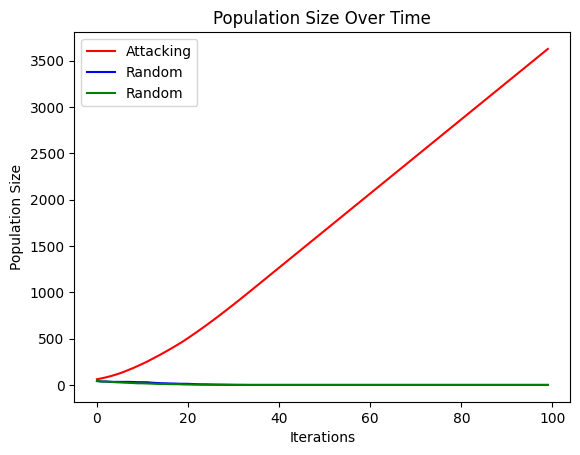

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 225.97283935546875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 225.97283935546875

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



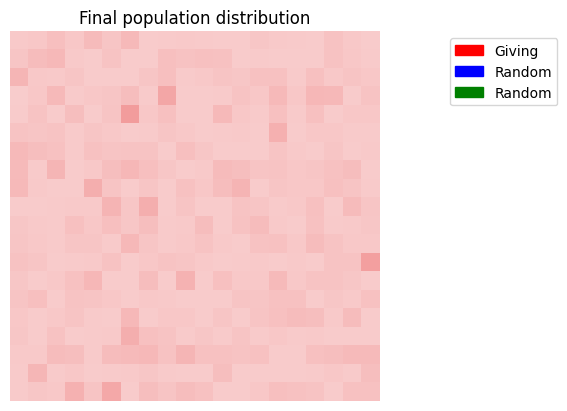

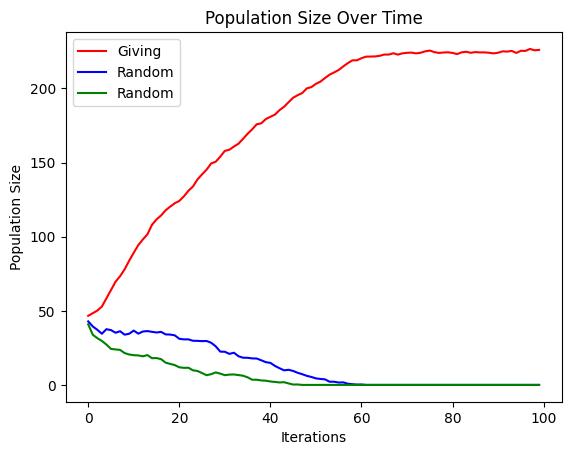

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 224.73233032226562
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.73233032226562

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



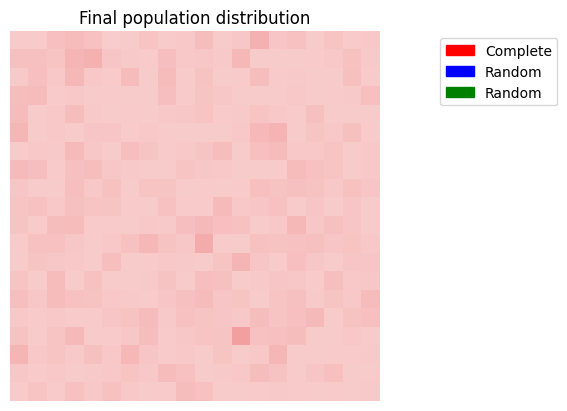

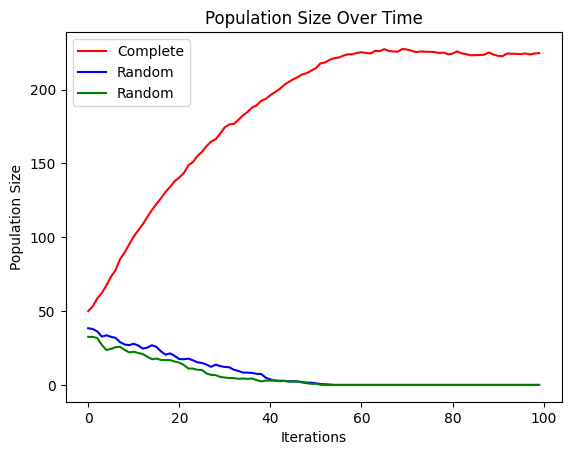

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 3186.0546875

Total fitness: 3186.0546875

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



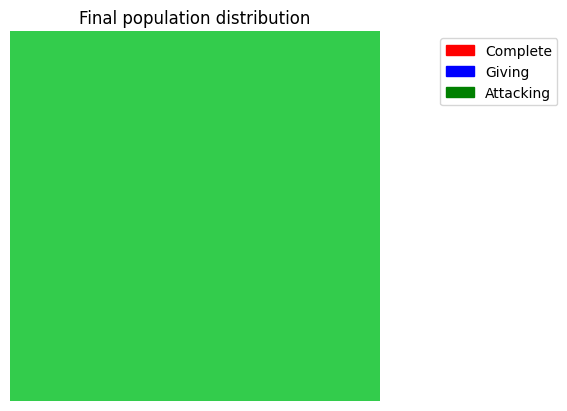

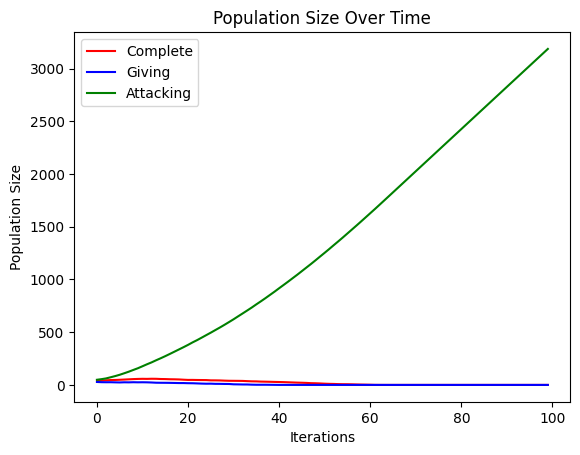

Creating simulation with parameters: bonus_1_0 - fitness_donation: 0.1 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 36.18736267089844
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 36.18736267089844

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



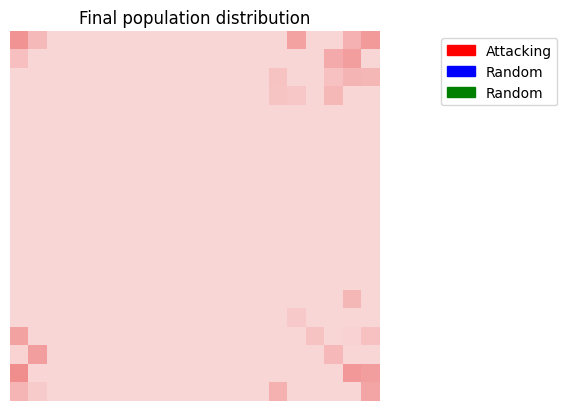

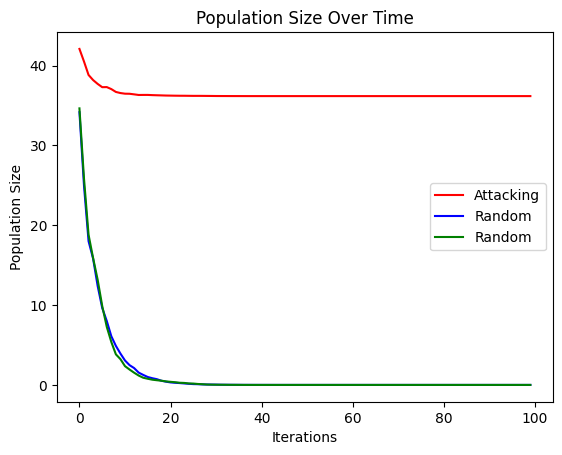

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 0.0
Population 2: random - 6.604087957384763e-06
Population 3: random - 2.2181269741849974e-05

Total fitness: 2.8785358153982088e-05

Final population %'s fitness:
Population 1: giving - 0.00%
Population 2: random - 22.94%
Population 3: random - 77.06%



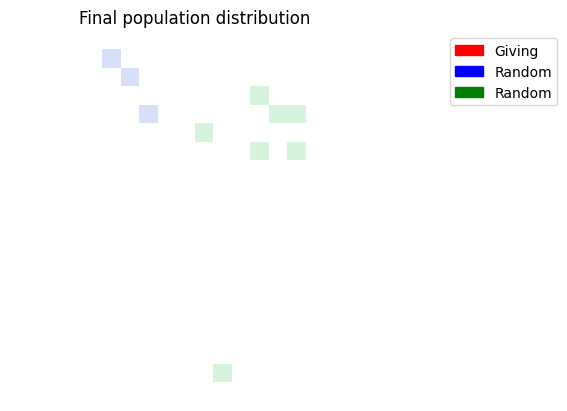

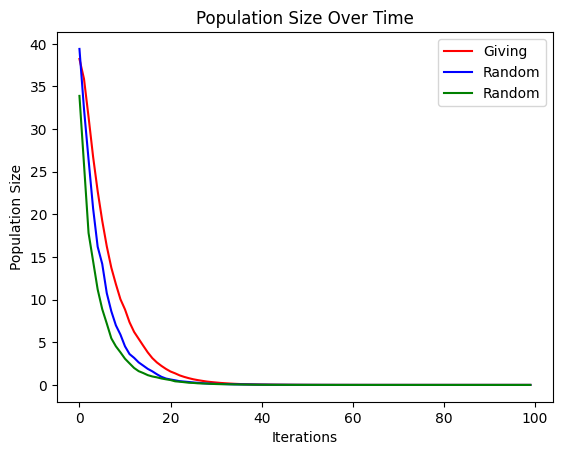

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 0.0
Population 2: random - 5.810839866171591e-06
Population 3: random - 0.0

Total fitness: 5.810839866171591e-06

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: random - 100.00%
Population 3: random - 0.00%



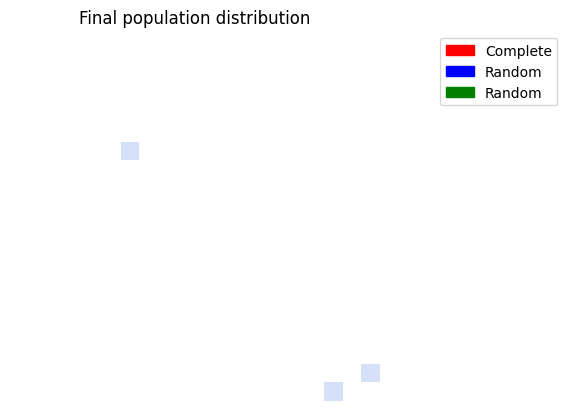

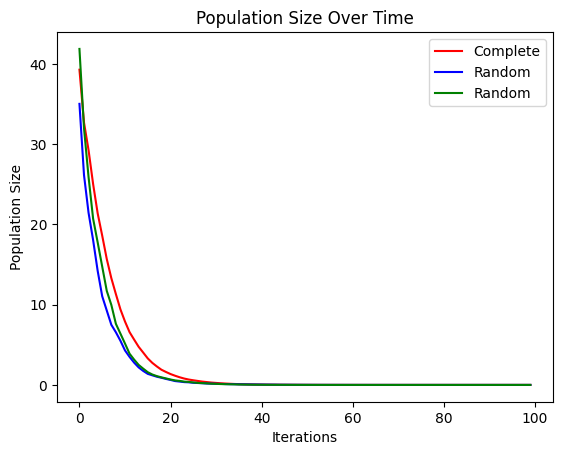

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 34.09693908691406

Total fitness: 34.09693908691406

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



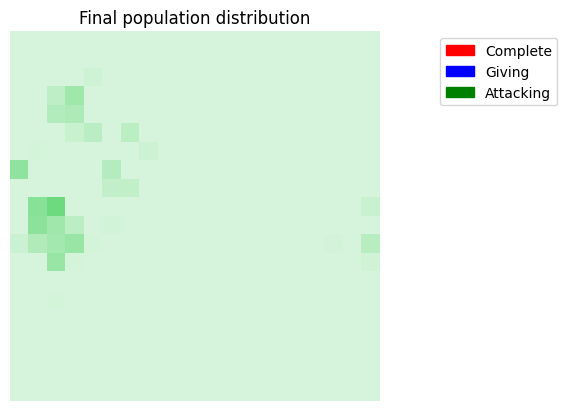

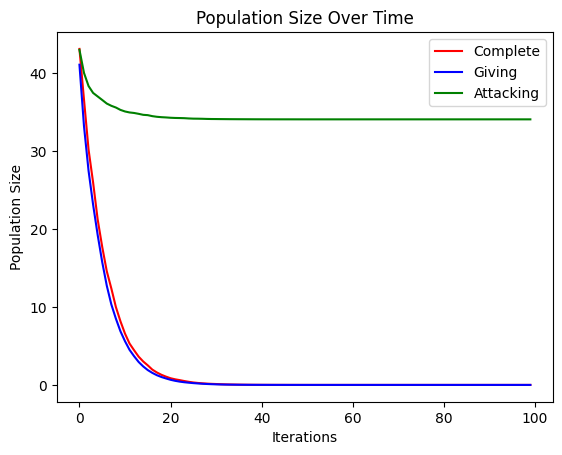

Creating simulation with parameters: bonus_1_1 - fitness_donation: 0.1 - fitness_growth: 0.1
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 3705.467529296875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 3705.467529296875

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



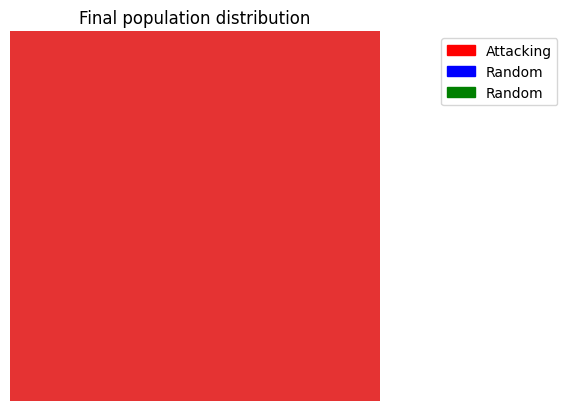

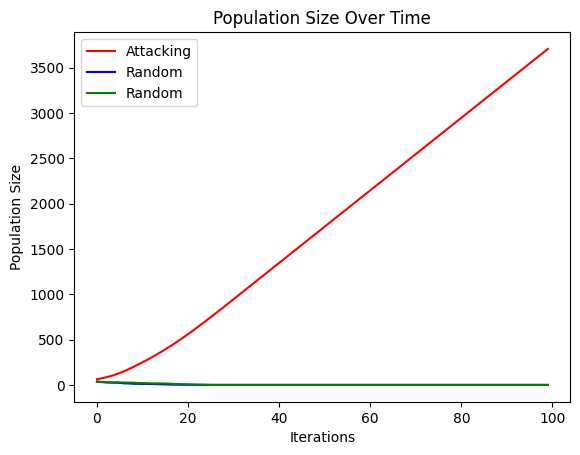

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 225.79273986816406
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 225.79273986816406

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



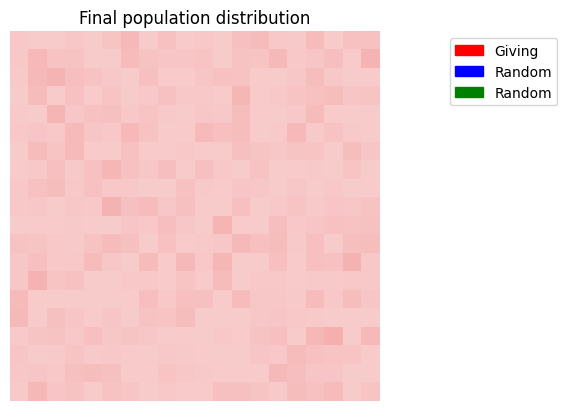

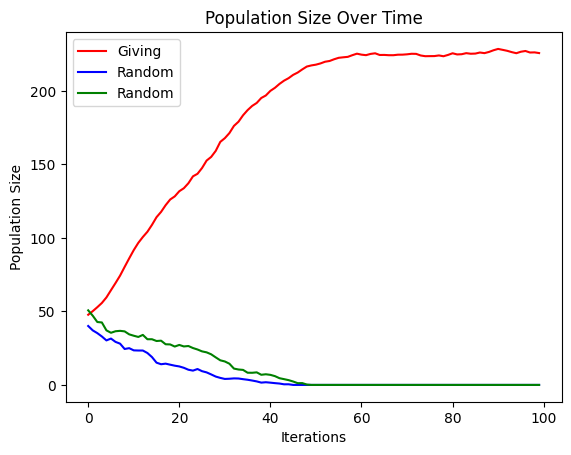

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 224.6608123779297
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.6608123779297

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



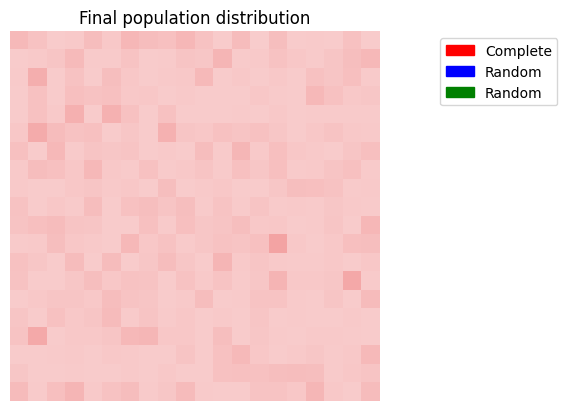

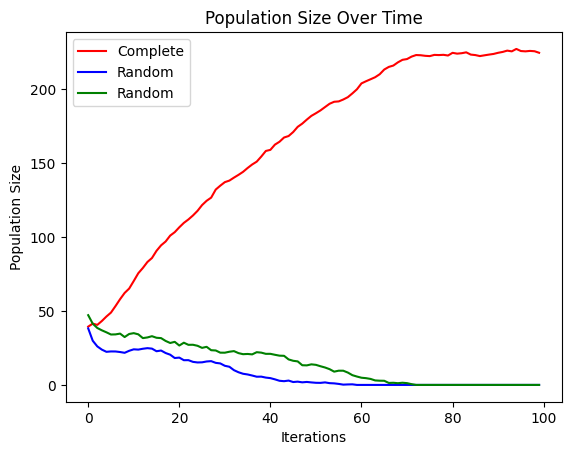

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 2964.22607421875

Total fitness: 2964.22607421875

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



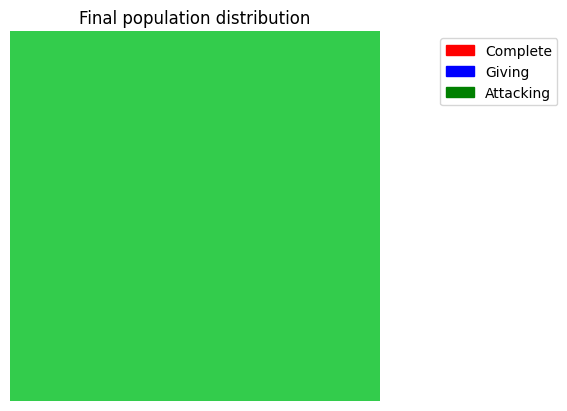

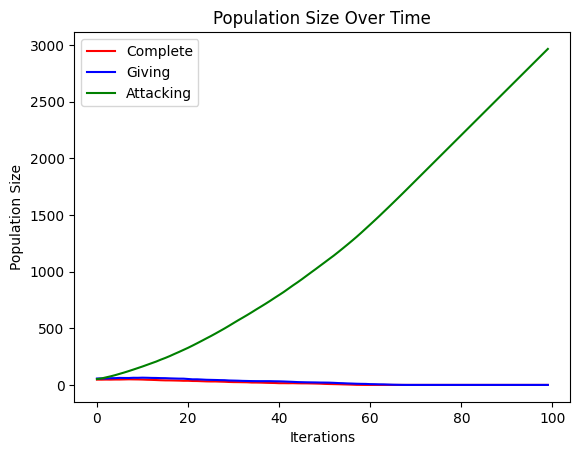

Creating simulation with parameters: bonus_2_0 - fitness_donation: 0.2 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 48.511444091796875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 48.511444091796875

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



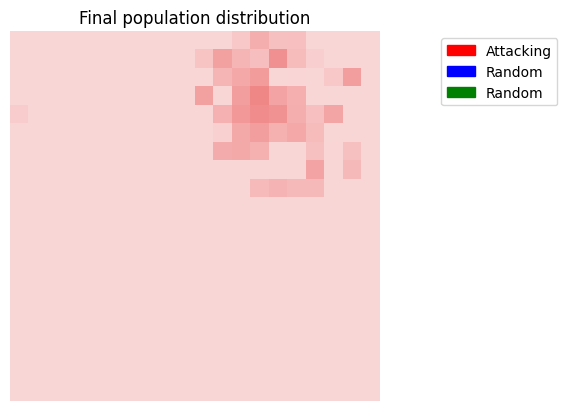

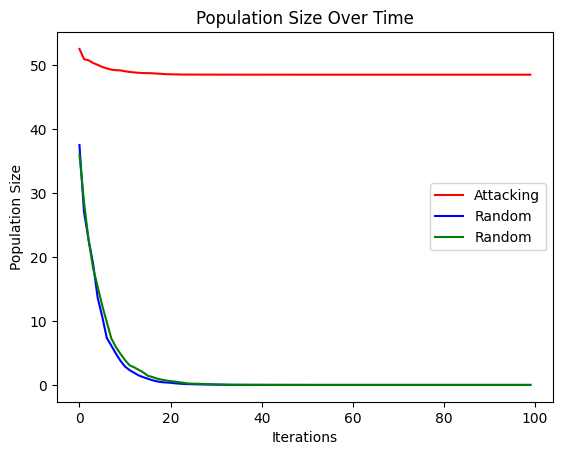

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 0.0
Population 2: random - 3.208858106518164e-05
Population 3: random - 4.888541752734454e-06

Total fitness: 3.6977122363168746e-05

Final population %'s fitness:
Population 1: giving - 0.00%
Population 2: random - 86.78%
Population 3: random - 13.22%



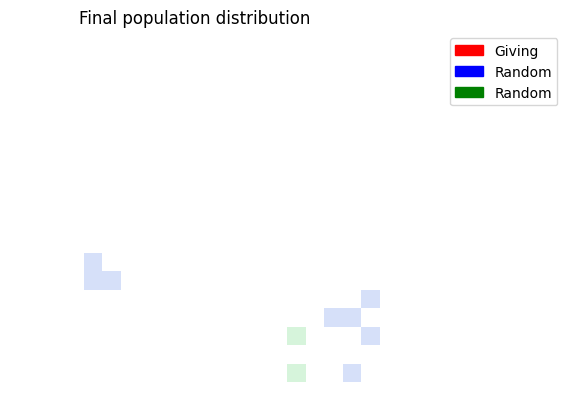

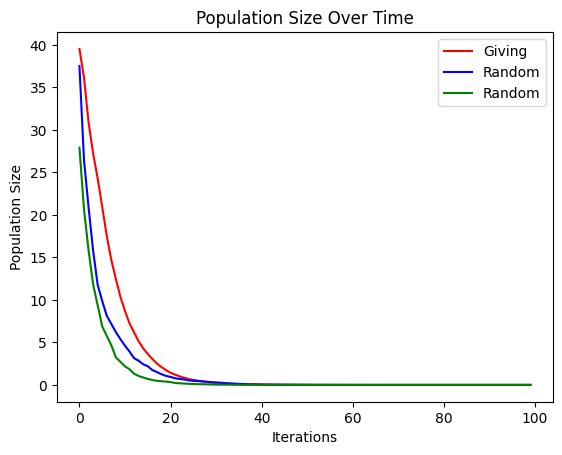

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 0.0
Population 2: random - 2.6495061320019886e-05
Population 3: random - 3.4729855542536825e-05

Total fitness: 6.12249132245779e-05

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: random - 43.27%
Population 3: random - 56.73%



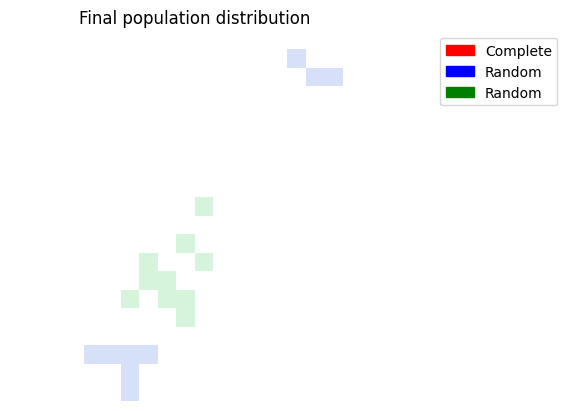

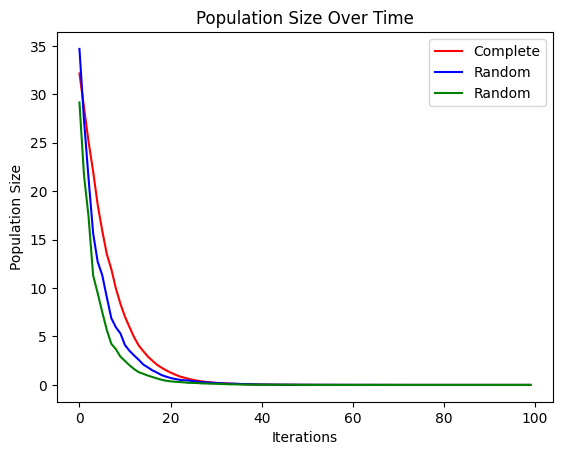

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 39.98385238647461

Total fitness: 39.98385238647461

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



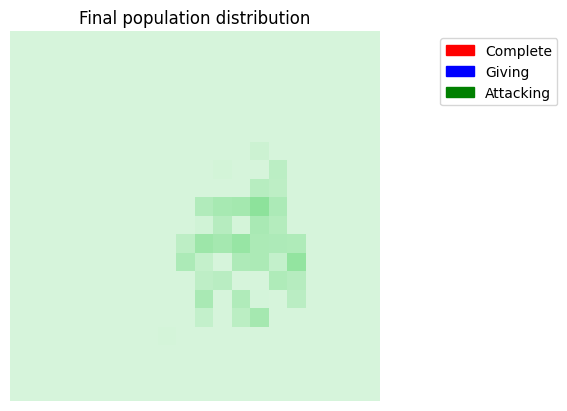

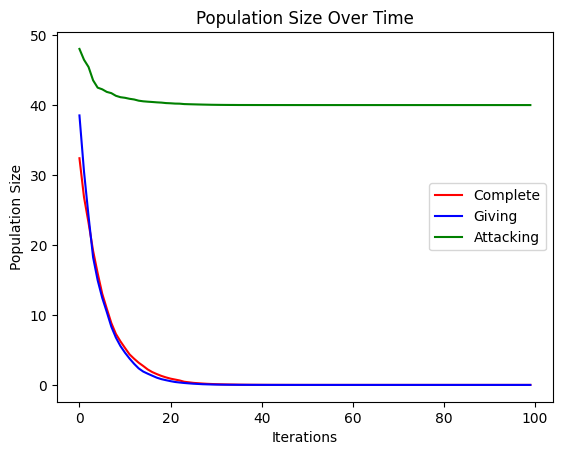

Creating simulation with parameters: bonus_2_1 - fitness_donation: 0.0 - fitness_growth: 0.2
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 7286.51953125
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 7286.51953125

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



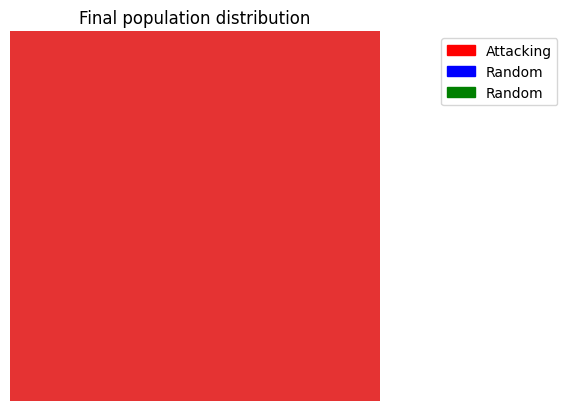

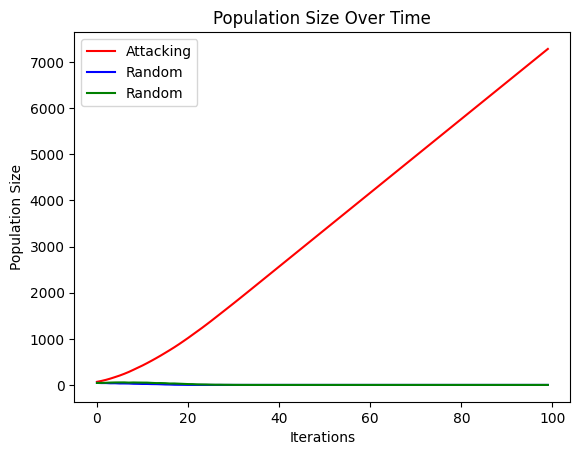

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 453.6712646484375
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 453.6712646484375

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



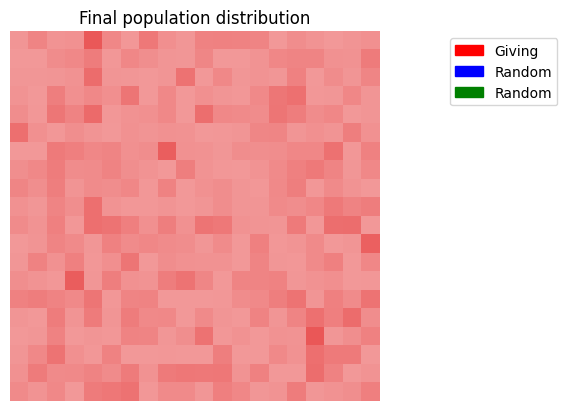

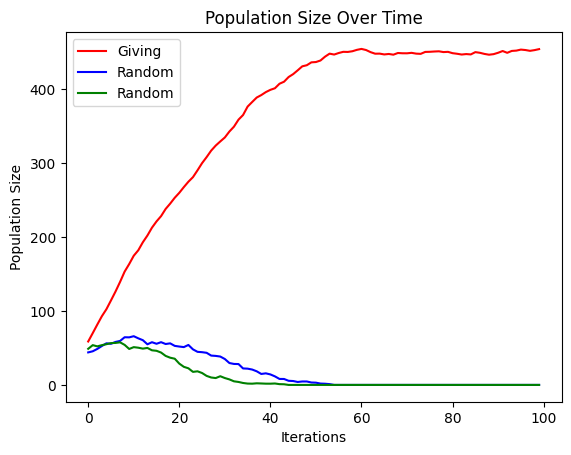

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 449.0694580078125
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 449.0694580078125

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



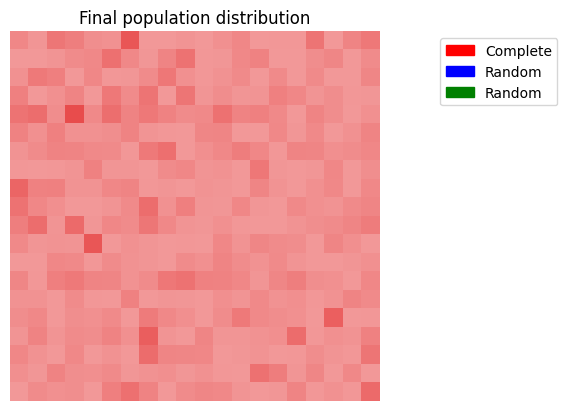

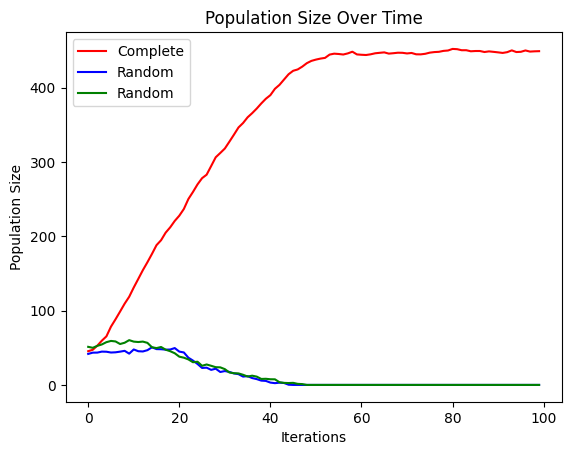

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 5252.2734375

Total fitness: 5252.2734375

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



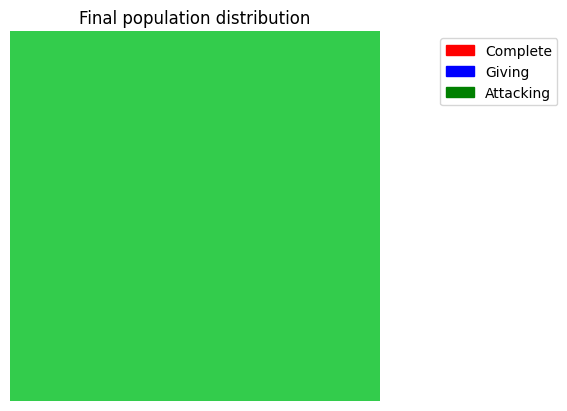

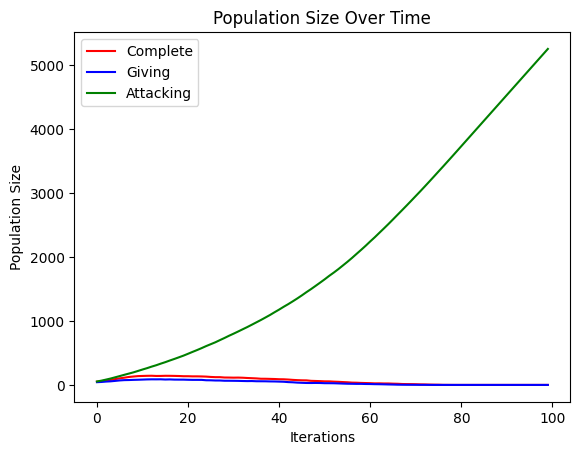

Creating simulation with parameters: bonus_2_2 - fitness_donation: 0.2 - fitness_growth: 0.2
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 7344.2587890625
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 7344.2587890625

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



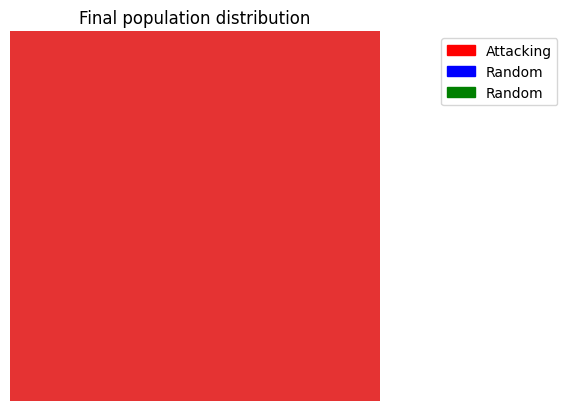

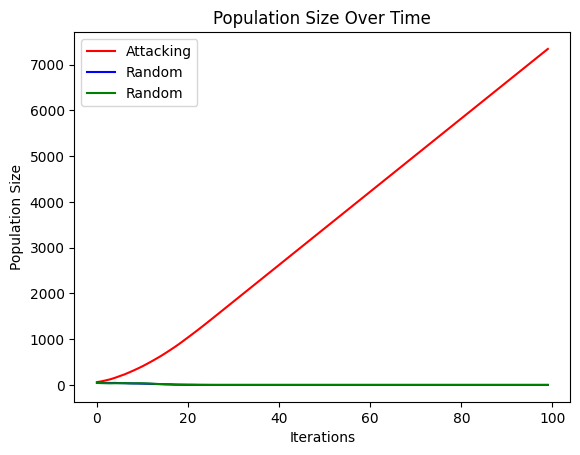

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 448.921630859375
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 448.921630859375

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



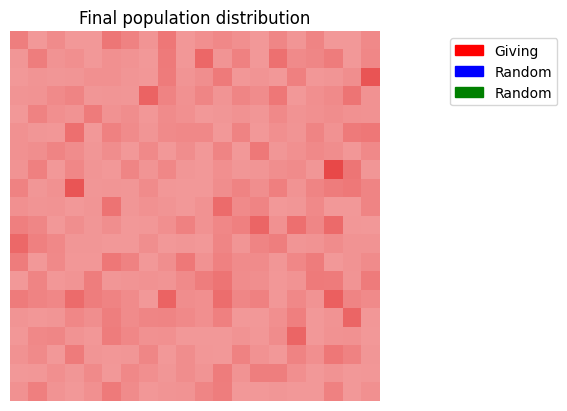

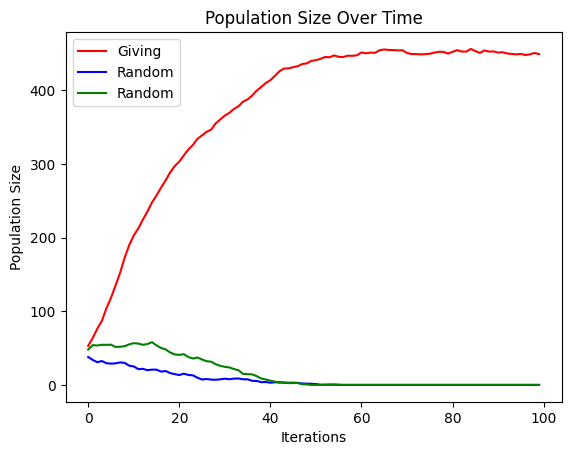

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 450.7154541015625
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 450.7154541015625

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



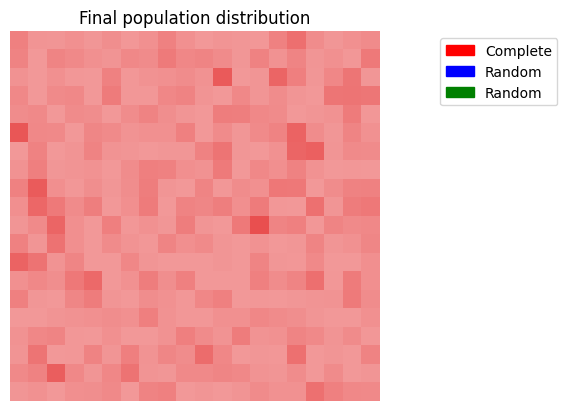

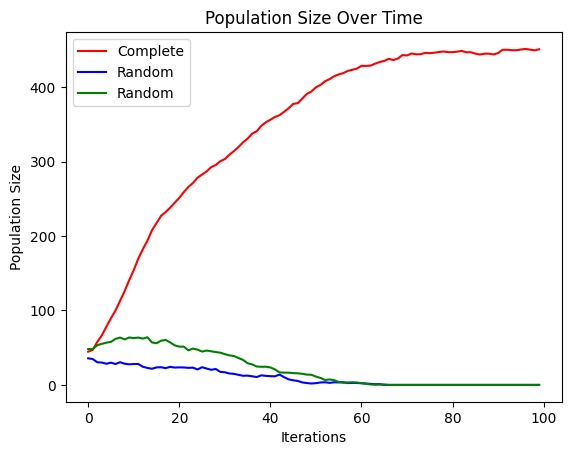

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 6234.87109375

Total fitness: 6234.87109375

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



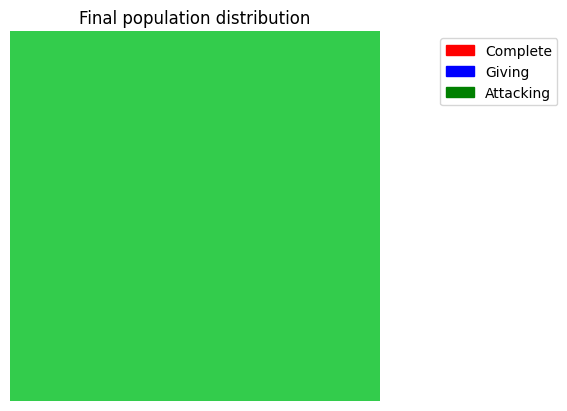

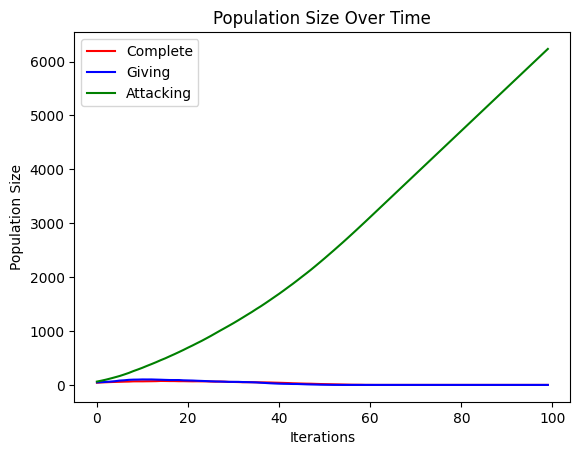

In [3]:
# if save_dir is None, the images will not be saved

simulation_parameters = [('bonus_0_0', 0.0, 0.0), ('bonus_0_1', 0.0, 0.1), ('bonus_1_0', 0.1, 0.0), ('bonus_1_1', 0.1, 0.1), ('bonus_2_0', 0.2, 0.0), ('bonus_2_1', 0.0, 0.2), ('bonus_2_2', 0.2, 0.2)]

all_results_string = 'pop1 total fitness; pop2 total fitness; pop2 total fitness; pop1 \% fitness; pop 2 \% fitness; pop 3 \% fitness \n'

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SAVE_DIR = os.path.join(parent_dir, 'simulation_imgs')
#SAVE_DIR = None

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)

# Number of iterations 
iterations = 100

# Simulation parameters
nb_batches = 1
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for tup in simulation_parameters:

    sub_dir_name = tup[0]
    fitness_donation = tup[1]
    fitness_growth = tup[2]

    title = f"don_{fitness_donation}_growth_{fitness_growth}"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "attack vs random"

    print("Creating simulation: attack vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'attackVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None
    results = get_results_imgs(simulation, iterations=iterations, save_dir=tmp_dir, type1='attacking', title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - attack vs random\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "giving vs random"
    print("Creating simulation: giving vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'givingVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='giving', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - giving vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "complete vs random"
    print("Creating simulation: complete vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - complete vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "giving vs attacking vs complete"
    print("Creating simulation: complete vs giving vs attacking")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsGivingVsAttacking')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', type2='giving', type3='attacking', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - complete vs giving vs attacking\n{results}\n"
        all_results_string += results_string + "\n"

if SAVE_DIR is not None:
    results_txt_path = os.path.join(SAVE_DIR, "results_summary.txt")
    with open(results_txt_path, "w") as f:
        f.write(all_results_string)
